In [3]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras import layers
#from keras.layers.normalization import BatchNormalization

In [4]:
from keras.datasets import cifar10

In [5]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
x_train.shape

(50000, 32, 32, 3)

In [7]:
y_train.shape

(50000, 1)

In [8]:
x_test.shape

(10000, 32, 32, 3)

In [9]:
y_test.shape

(10000, 1)

In [10]:
# prepariamo i dati
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

In [11]:
# convertiamo in variabile categorica le classificazioni
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

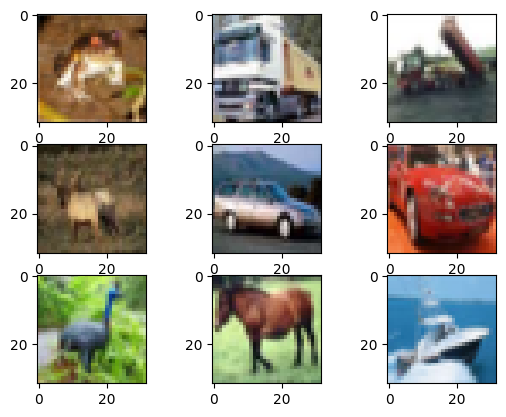

In [14]:
for i in range(0, 9):
    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i])

In [ ]:
# creiamo il modello

In [15]:
model = Sequential()

model.add(layers.Conv2D(32, kernel_size=(3, 3), input_shape=(32, 32, 3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), padding='same'))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), padding='same'))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(128, kernel_size=(3, 3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(128, kernel_size=(3, 3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), padding='same'))
model.add(layers.Dropout(0.25))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,403,050 (5.35 MB)

 Trainable params: 1,403,050 (5.35 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(x_train, y_train, batch_size=256, epochs=20, verbose=1, validation_data=(x_test, y_test))

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.2955 - loss: 1.8729 - val_accuracy: 0.4458 - val_loss: 1.4796
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.4904 - loss: 1.3820 - val_accuracy: 0.5573 - val_loss: 1.2175
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.5863 - loss: 1.1474 - val_accuracy: 0.6152 - val_loss: 1.0848
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.6366 - loss: 1.0155 - val_accuracy: 0.6690 - val_loss: 0.9487
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.6720 - loss: 0.9272 - val_accuracy: 0.7074 - val_loss: 0.8249
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.7035 - loss: 0.8386 - val_accuracy: 0.7239 - val_loss: 0.7649
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.7236 - loss: 0.7828 - val_accuracy: 0.7502 - val_loss: 0.7100
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - accuracy: 0.7440 - loss: 0.7284 - val_accu

In [ ]:
score = model.evaluate(x_test, y_test, verbose=1)

 9984/10000 [============================>.] - ETA: 0s

In [ ]:
score

[0.5754188484668732, 0.8094]